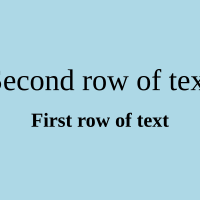

In [5]:
import drawsvg as draw

# Create a drawing
d = draw.Drawing(200, 200, origin='center', displayInline=False)

# Create a rectangle with a background color
rect = draw.Rectangle(-100, -100, 200, 200, fill='lightblue')
d.append(rect)

# Add two lines of text, with the first line in bold and the second line larger
text1 = draw.Text('First row of text', 20, 0, 20, center=True, fill='black', font_weight='bold')
text2 = draw.Text('Second row of text', 30, 0, -20, center=True, fill='black')  # Increased font size to 30
d.append(text1)
d.append(text2)


# Display the drawing
d


In [22]:
import pandas as pd
import drawsvg as draw

In [2]:
master_df = pd.read_csv(r'C:\Users\Neil\Documents\Projects\Electoral-PH\Electoral-PH\image_creator\static\data\master_data.csv', index_col=0)

In [10]:
master_df = master_df.astype({'year':str})
master_df['votes'] = pd.to_numeric(master_df['votes'])
master_df.head()

,year,position,province,color,candidate,votes
0,2004,President,Abra,#B0E0E6,Gloria_Arroyo,32644
1,2004,President,Agusan del Norte,#B0E0E6,Gloria_Arroyo,138402
2,2004,President,Agusan del Sur,#B0E0E6,Gloria_Arroyo,100998
3,2004,President,Aklan,#B0E0E6,Gloria_Arroyo,87197
4,2004,President,Albay,#B0E0E6,Gloria_Arroyo,172777


In [15]:
df = master_df.loc[(master_df['year']=='2004') &( master_df['position']=='President')]
df = df.sort_values(by=['province']).reset_index(drop=True)
df.head()

,year,position,province,color,candidate,votes
0,2004,President,Abra,#B0E0E6,Gloria_Arroyo,32644
1,2004,President,Abra,#9683EC,Raul_Roco,2251
2,2004,President,Abra,#C4C4FF,Panfilo_Lacson,11256
3,2004,President,Abra,#0038A8,Fernando_Poe_Jr,50866
4,2004,President,Abra,#3F9727,Eddie_Villanueva,3741


In [17]:
idx = df.groupby('province')['votes'].idxmax()
df = df.loc[idx]

In [21]:
df.iloc[0]['color']

'#0038A8'

In [8]:
electors_df = pd.read_csv(r'C:\Users\Neil\Documents\Projects\Electoral-PH\Electoral-PH\image_creator\static\data\2004_Reps.csv', index_col=0)
electors_df.head()

,province,province_id,electors
0,Abra,1,1
1,Agusan del Norte,2,2
2,Agusan del Sur,3,1
3,Aklan,4,1
4,Albay,5,3


In [28]:
electors_df.loc[electors_df['province'] == 'Albay', 'electors'].values[0]

3

year                    2004
position           President
province                Abra
color                #0038A8
candidate    Fernando_Poe_Jr
votes                  50866
Name: 3, dtype: object

In [204]:
#import drawSvg as draw
import textwrap

def create_box(province, electors, color, font_size=40, factor=1):
    # Create a drawing
    d = draw.Drawing(200*factor, 200*factor, origin='center', displayInline=False)

    # Create a rectangle with a background color
    rect = draw.Rectangle(-100*factor, -100*factor, 200*factor, 200*factor, fill=color, stroke='white', stroke_width=2)
    d.append(rect)

    # Function to split text into two lines if it's too wide
    def split_text(text, max_width):
        wrapped_text = textwrap.fill(text, width=max_width)
        lines = wrapped_text.split(' ', 1)
        try:
            return lines[1], lines[0]

        except:
            return lines[0], None

    # Split the province text if necessary
    max_width = font_size  # Adjust this value based on your box size and font size
    top, bottom = split_text(province, max_width)

    # Add the text to the drawing
    province_top = draw.Text(top, font_size, 0, -20 if bottom else -30, center=True, fill='black', stroke='white', stroke_width='0.125')
    if bottom is not None:
        province_bottom = draw.Text(bottom, font_size, 0, -55, center=True, fill='black', stroke='white', stroke_width='0.125')
    electors_txt = draw.Text(str(electors), 50, 0, 35, center=True, fill='black', font_weight='bold',stroke='white', stroke_width='0.125')

    d.append(electors_txt)
    d.append(province_top)
    if bottom:
        d.append(province_bottom)

    return d


In [205]:
test = df.iloc[63]
test

year                      2004
position             President
province     Negros Occidental
color                  #B0E0E6
candidate        Gloria_Arroyo
votes                   479211
Name: 315, dtype: object

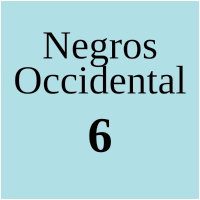

In [206]:
d = create_box(test['province'], electors_df.loc[electors_df['province'] == test['province'], 'electors'].values[0], test['color'])
d

In [78]:
d = create_box("Example Province", 12345, 'lightblue')

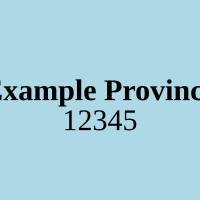

In [79]:
d

In [207]:
def create_combined_svg(boxes, columns=2):
    rows = (len(boxes) + columns - 1) // columns
    combined_width = 200 * columns
    combined_height = 200 * rows
    combined_svg = draw.Drawing(combined_width, combined_height, origin='center', displayInline=False)

    for i, box in enumerate(boxes):
        col = i % columns
        row = i // columns
        box.translate(200 * col - combined_width / 2 + 100, combined_height / 2 - 200 * row - 100)
        combined_svg.append(box)

    return combined_svg

In [208]:
# Example usage
boxes = [
    create_box("Province 1", 10, 'red'),
    create_box("Province 2", 20, 'blue'),
    create_box("Province 3", 30, 'green'),
    create_box("Province 4", 40, 'yellow')
]

In [209]:
create_combined_svg(boxes)

AttributeError: 'Drawing' object has no attribute 'translate'